# Analysis and Inference of replicates`1 2 and 3`
This notebook plots the data from three different experiments and the agent-based model. The parameters of this agent-based models were inferred using particle swarm algorithm and the growth curves from those experiments. 

### Import all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update(matplotlib.rcParamsDefault)

### Load the experimental data as a dataframe

In [2]:
df = pd.read_csv("../data/experiments/growth_curves_57-58-59_swapcols.csv", header=[0,1],index_col=0)#.drop("Unnamed: 0", axis=1)
df[df.columns[::2]] = df[df.columns[::2]].dropna().astype(int)
df.columns

MultiIndex([(   'E57_KO_10uM_cyto3', 'counts'),
            (   'E57_KO_10uM_cyto3',   'time'),
            (  'E57_KO_500uM_cyto3', 'counts'),
            (  'E57_KO_500uM_cyto3',   'time'),
            ('E57_KO_Control_cyto3', 'counts'),
            ('E57_KO_Control_cyto3',   'time'),
            (   'E57_KO_DMSO_cyto3', 'counts'),
            (   'E57_KO_DMSO_cyto3',   'time'),
            (   'E57_WT_10uM_cyto3', 'counts'),
            (   'E57_WT_10uM_cyto3',   'time'),
            (  'E57_WT_500uM_cyto3', 'counts'),
            (  'E57_WT_500uM_cyto3',   'time'),
            ('E57_WT_Control_cyto3', 'counts'),
            ('E57_WT_Control_cyto3',   'time'),
            (   'E57_WT_DMSO_cyto3', 'counts'),
            (   'E57_WT_DMSO_cyto3',   'time'),
            (   'E58_KO_10uM_cyto3', 'counts'),
            (   'E58_KO_10uM_cyto3',   'time'),
            (  'E58_KO_500uM_cyto3', 'counts'),
            (  'E58_KO_500uM_cyto3',   'time'),
            ('E58_KO_Control_cyto3', 'co

In [61]:
df.head()

E57_KO_10uM_cyto3       E57_KO_500uM_cyto3       E57_KO_Control_cyto3        \
             counts  time             counts  time               counts  time   
0               499   0.0                445   0.0                  406   0.0   
1               532   3.0                448   3.0                  424   3.0   
2               576   6.0                460   6.0                  448   6.0   
3               535   9.0                492   9.0                  462   9.0   
4               550  12.0                465  12.0                  475  12.0   

  E57_KO_DMSO_cyto3       E57_WT_10uM_cyto3        ... E59_KO_DMSO_cyto3  \
             counts  time            counts  time  ...            counts   
0               216   0.0               511   0.0  ...              1335   
1               254   3.0               533   3.0  ...              1422   
2               237   6.0               558   6.0  ...              1465   
3               275   9.0               603   9.0  ...              1541   
4               254  12.0               658  12.0  ...              1585   

        E59_WT_10uM_cyto3       E59_WT_500uM_cyto3       E59_WT_Control_cyto3  \
   time            counts  time             counts  time               counts   
0   0.0               906   0.0                834   0.0                  715   
1   3.0              1026   3.0                970   3.0                  773   
2   6.0              1083   6.0                976   6.0                  791   
3   9.0              1145   9.0               1015   9.0                  803   
4  12.0              1202  12.0               1068  12.0                  863   

        E59_WT_DMSO_cyto3        
   time            counts  time  
0   0.0               793   0.0  
1   3.0               904   3.0  
2   6.0               958   6.0  
3   9.0               986   9.0  
4  12.0              1034  12.0  

[5 rows x 48 columns]

In [5]:
DMSO = [
    "E57_WT_Control_cyto3",
    "E58_WT_Control_cyto3",
    "E59_WT_Control_cyto3",
]

TMZ10 = [
    'E57_WT_10uM_cyto3',
    'E58_WT_10uM_cyto3',
    'E59_WT_10uM_cyto3',
]

TMZ500 = [
    'E57_WT_500uM_cyto3',
    'E58_WT_500uM_cyto3',
    'E59_WT_500uM_cyto3',
]

df.loc[:, (DMSO,'counts')].head()

,E57_WT_Control_cyto3,E58_WT_Control_cyto3,E59_WT_Control_cyto3
,counts,counts,counts
0,372,405,715
1,391,469,773
2,423,497,791
3,449,542,803
4,474,561,863


## Plot the fold change over time
We want to compare the _DMSO_ control and the 500 uM _TMZ_ treamtments. To calculate the fold change in cell numbers we normalize the timeseries by dividing with the 11th observation.

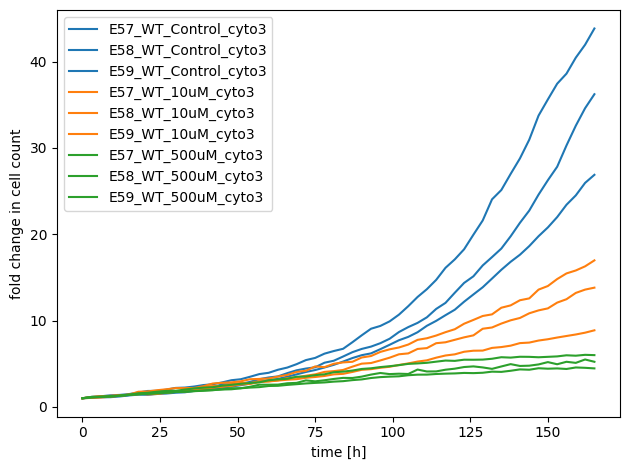

In [6]:
fig, ax = plt.subplots()
for treatment, color in zip([DMSO, TMZ10, TMZ500], ["C{}".format(i) for i in range(3)]):
    #(df.swaplevel(0,1,axis=1).loc[:, (treatment)]).plot(x='time',y='counts',ax = ax, color = color,)
    for e in treatment:
        x = df.loc[:,(e,'time')]
        y = df.loc[:,(e,'counts')]/df.loc[0,(e,'counts')]
        ax.plot(x,y, color = color,label=e)
plt.xlabel("time [h]")
plt.ylabel("fold change in cell count")
plt.legend()
plt.tight_layout()

### Plot the predicted fold change
Using the above data points we parametried an agent-based model. This model explicitly considers cell two abstract cell cycle stages; 1. where cells get methylated by TMZ, and 2. where methylated cells die. The cell populations cycles through these stages. One model step is equivalent of 30 min timestep, which is referred to as one unit of time. The model consists of following parameters:
- `l1`: lenght of the stage (in multiple of time units) where neither methylation nor death occurs
- `l2`: length of the stage (in multiple of time units) where methylation occurs
- `L`: length of the cell cycle (in multiple of time units), i.e. doubling time
- `p_drug10`: the probability of methylation in one unit of time for 10um Temozolomide
- `p_drug500`: the probability of methylation in one unit of time for 500um Temozolomide

In [78]:
# if desired, you need to run the following to regenerate the data by going into the "simulations" folder 
# and running the code: julia --project=. inference.jl

parameters = pd.read_csv("../data/inference/parameters_57-58-59.csv", header=None).iloc[:,0].to_list()
parameters
print("\n--- Best-fit parameter values ---")
for name, p in zip(["l1","l2","L","p_drug10","p_drug500"], parameters):
    if len(name) <= 2: print(name, " : ", int(p))
    else: print(name, " : ", r"{:.3f} h^-1 ".format(2*p))


--- Best-fit parameter values ---
l1  :  9
l2  :  12
L  :  66
p_drug10  :  0.051 h^-1 
p_drug500  :  0.109 h^-1 


In case of _DMSO_ we assume that the probability of methylation `p_drug = 0`. The trajectories corresponding to the best-fit parameters are plotted below.

<Figure size 350x350 with 0 Axes>

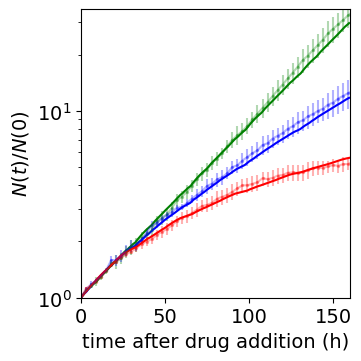

In [80]:
pdf = pd.read_csv("../data/inference/fitted_exp57-58-59.csv")
frame_h = 0.5 # time between each timepoint
t0 = 0 
pdf['time'] = pdf.step*frame_h
#x = np.arange(0,len(df))*frame_h
x = df.xs('time',axis=1,level=1).mean(axis=1)

plt.figure()


plt.rcParams['font.size'] = '14'
plt.rcParams["figure.figsize"] = (3.5,3.5)
plt.figure(constrained_layout=True)


for exp,c,lab in zip([DMSO,TMZ10,TMZ500],
                      ['g','b','r'],
                      ['control','10uM TMZ','500uM TMZ']
                    ): 

    ys = df.loc[:, (exp,'counts')]
    y_fold = ys/ys.loc[t0]
    y = y_fold.mean(axis=1)
    yerr = y_fold.std(axis=1)/(np.sqrt(len(exp)))
    plt.scatter(x,  y, alpha=0.3,s=2, color=c)
    plt.errorbar(x, y , yerr= yerr , alpha=0.3, color=c)



plt.plot(pdf.time, (pdf.DMSO) / (pdf.DMSO)[t0], label="control", color="g")
plt.plot(pdf.time, (pdf.TMZ10) / (pdf.TMZ10)[t0], label="10um TMZ", color="b")
plt.plot(pdf.time, (pdf.TMZ500) / (pdf.TMZ500)[t0], label="500um TMZ", color="r")
plt.xlabel("time after drug addition (h)")
plt.ylabel("$N(t)/N($"+str(t0)+")")
plt.xlim(0,160)
plt.ylim(1,35)
#plt.legend()
plt.yscale('log')
plt.savefig('../figures/growth_curves_stderr.svg')#,dpi=300)
